# Model train - 1 (salary prediction) ->  hands-on 

In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [29]:
df = pd.read_csv(r"C:\Users\Vignesh R\Downloads\dataset.csv")

In [30]:
df.head()

,age,experience_years,education_level,hours_per_week,salary
0,56,14,2,37,164160
1,46,7,1,50,106211
2,32,9,1,41,36124
3,60,4,1,33,23819
4,25,18,2,37,115822


In [31]:
df.count()

age                 10000
experience_years    10000
education_level     10000
hours_per_week      10000
salary              10000
dtype: int64

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               10000 non-null  int64
 1   experience_years  10000 non-null  int64
 2   education_level   10000 non-null  int64
 3   hours_per_week    10000 non-null  int64
 4   salary            10000 non-null  int64
dtypes: int64(5)
memory usage: 390.8 KB


In [33]:
# set-up the respective variable 

X = df[['age','experience_years','education_level','hours_per_week']]
Y = df[['salary']]

In [34]:
# just split the data for training and testing.
# training - 8000
# testing - 2000

x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.2,
    random_state = 42
)

In [35]:
x_train.count()

age                 8000
experience_years    8000
education_level     8000
hours_per_week      8000
dtype: int64

In [36]:
y_train.count()

salary    8000
dtype: int64

In [37]:
x_test.count()

age                 2000
experience_years    2000
education_level     2000
hours_per_week      2000
dtype: int64

In [38]:
y_test.count()

salary    2000
dtype: int64

In [39]:
# training data feeding to the model.

model_1 = sm.OLS(y_train,x_train)
result = model_1.fit()

In [40]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 salary   R-squared (uncentered):                   0.789
Model:                            OLS   Adj. R-squared (uncentered):              0.789
Method:                 Least Squares   F-statistic:                              7494.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):                        0.00
Time:                        12:29:46   Log-Likelihood:                         -98803.
No. Observations:                8000   AIC:                                  1.976e+05
Df Residuals:                    7996   BIC:                                  1.976e+05
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
age                819.7491     38.244     21.435      0.000     744.781     894.717
experience_years   600.0289     51.980     11.543      0.000     498.134     701.924
education_level   1.151e+04    682.952     16.852      0.000    1.02e+04    1.28e+04
hours_per_week     856.2049     35.303     24.253      0.000     787.002     925.408
==============================================================================
Omnibus:                     1261.852   Durbin-Watson:                   1.992
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              288.238
Skew:                          -0.022   Prob(JB):                     2.57e-63
Kurtosis:                       2.071   Cond. No.                         71.1
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# model accuracy is approx (80%)
# but want to test the model , wheather this model's prediction is accurate or not.

Assumptions checks:

1.linearity check :

In [46]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import matplotlib.pyplot as plt
df.head()

,age,experience_years,education_level,hours_per_week,salary
0,56,14,2,37,164160
1,46,7,1,50,106211
2,32,9,1,41,36124
3,60,4,1,33,23819
4,25,18,2,37,115822


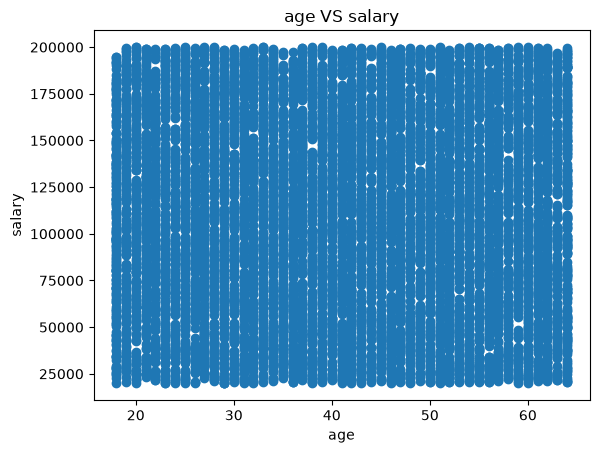

In [61]:
# age vs salary

plt.scatter(
    df['age'],
    df['salary']
)

plt.xlabel('age')
plt.ylabel('salary')
plt.title('age VS salary')
plt.show()

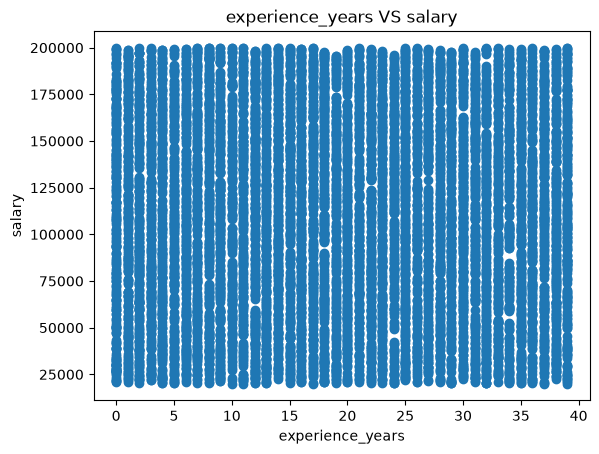

In [56]:
# experience_years vs salary

plt.scatter(
    df['experience_years'],
    df['salary']
)

plt.xlabel('experience_years')
plt.ylabel('salary')
plt.title('experience_years VS salary')
plt.show()

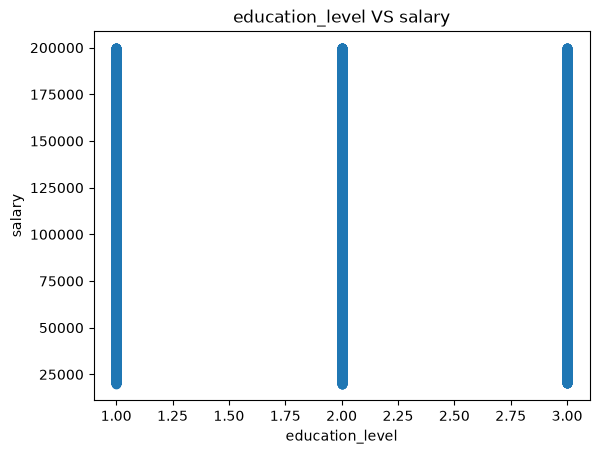

In [60]:
# education_level vs salary

plt.scatter(
    df['education_level'],
    df['salary']
)

plt.xlabel('education_level')
plt.ylabel('salary')
plt.title('education_level VS salary')
plt.show()

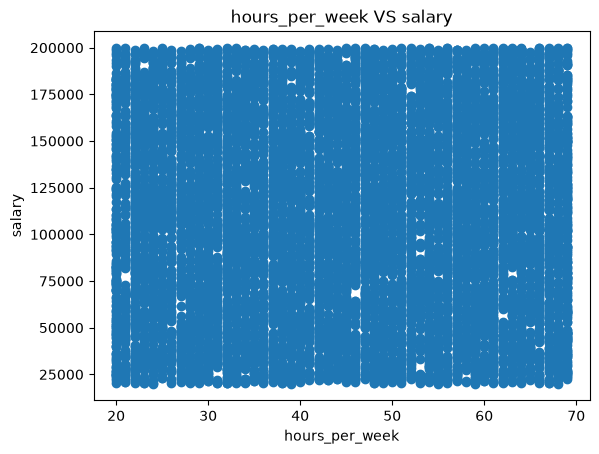

In [59]:
# hours_per_week vs salary

plt.scatter(
    df['hours_per_week'],
    df['salary']
)

plt.xlabel('hours_per_week')
plt.ylabel('salary')
plt.title('hours_per_week VS salary')
plt.show()

Multi-collinearity check:

In [64]:
df.corr()

# each variable doesn't correlate with each other.
# eg : age	vs salary = -0.001379 -> which is very low.
# eg : experience_years vs salary = 0.005753 -> very low

,age,experience_years,education_level,hours_per_week,salary
age,1.000000,0.003307,0.004928,-0.012789,-0.001379
experience_years,0.003307,1.000000,0.001793,-0.003057,0.005753
education_level,0.004928,0.001793,1.000000,0.006096,0.004083
hours_per_week,-0.012789,-0.003057,0.006096,1.000000,0.010793
salary,-0.001379,0.005753,0.004083,0.010793,1.000000


Independence of error check:

In [86]:
# now, testing the model performance & perdiction by feeding the testing data into the model.
df['predicted_salary'] = result.predict(x_test)

# this give the difference between the actual salary and the predicted salary. 
df['residue'] = df['predicted_salary'] - df['salary']

In [87]:
df.head()

,age,experience_years,education_level,hours_per_week,salary,predicted_salary,residue,hours_per_week_log,predicted_salary_log,salary_log
0,56,14,2,37,164160,109004.493263,-55155.506737,3.610918,11.599144,12.008597
1,46,7,1,50,106211,NaN,NaN,3.912023,11.474478,11.573183
2,32,9,1,41,36124,NaN,NaN,3.713572,11.267612,10.494713
3,60,4,1,33,23819,91349.100814,67530.100814,3.496508,11.422444,10.078239
4,25,18,2,37,115822,NaN,NaN,3.610918,11.362014,11.659810


In [78]:
# applying log for 3 variables. to get some idea.

df['hours_per_week_log'] = np.log(df['hours_per_week'])
df['predicted_salary_log'] = np.log(df['predicted_salary'])
df['salary_log'] = np.log(df['salary'])

In [79]:
df.head()

,age,experience_years,education_level,hours_per_week,salary,predicted_salary,residue,hours_per_week_log,predicted_salary_log,salary_log
0,56,14,2,37,164160,109004.493263,55155.506737,3.610918,11.599144,12.008597
1,46,7,1,50,106211,96228.182900,9982.817100,3.912023,11.474478,11.573183
2,32,9,1,41,36124,78245.909938,-42121.909938,3.713572,11.267612,10.494713
3,60,4,1,33,23819,91349.100814,-67530.100814,3.496508,11.422444,10.078239
4,25,18,2,37,115822,85992.387419,29829.612581,3.610918,11.362014,11.659810


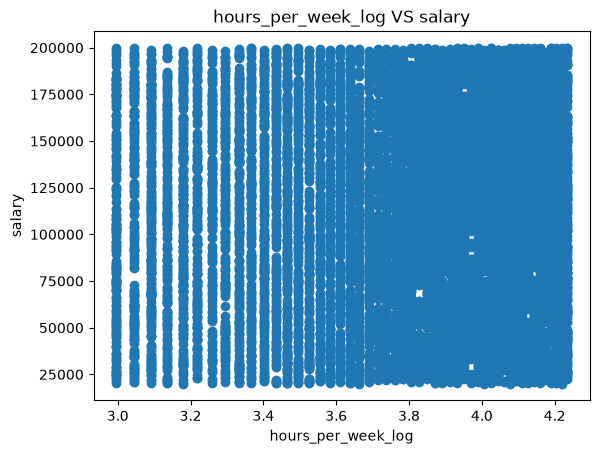

In [81]:
plt.scatter(
    df['hours_per_week_log'],
    df['salary']
)

plt.xlabel('hours_per_week_log')
plt.ylabel('salary')
plt.title('hours_per_week_log VS salary')
plt.show()

In [83]:
df.corr()

# this is summary correlation of variables.

,age,experience_years,education_level,hours_per_week,salary,predicted_salary,residue,hours_per_week_log,predicted_salary_log,salary_log
age,1.000000,0.003307,0.004928,-0.012789,-0.001379,0.543737,-0.198460,-0.013378,0.539546,-0.006717
experience_years,0.003307,1.000000,0.001793,-0.003057,0.005753,0.340954,-0.118255,-0.003688,0.338396,0.009835
education_level,0.004928,0.001793,1.000000,0.006096,0.004083,0.473210,-0.167776,0.006000,0.469073,0.003613
hours_per_week,-0.012789,-0.003057,0.006096,1.000000,0.010793,0.601885,-0.208159,0.987264,0.596207,0.013027
salary,-0.001379,0.005753,0.004083,0.010793,1.000000,0.009657,0.931944,0.010831,0.008798,0.963094
predicted_salary,0.543737,0.340954,0.473210,0.601885,0.009657,1.000000,-0.353586,0.593571,0.991457,0.009257
residue,-0.198460,-0.118255,-0.167776,-0.208159,0.931944,-0.353586,1.000000,-0.205109,-0.351292,0.897566
hours_per_week_log,-0.013378,-0.003688,0.006000,0.987264,0.010831,0.593571,-0.205109,1.000000,0.592998,0.012857
predicted_salary_log,0.539546,0.338396,0.469073,0.596207,0.008798,0.991457,-0.351292,0.592998,1.000000,0.008233
salary_log,-0.006717,0.009835,0.003613,0.013027,0.963094,0.009257,0.897566,0.012857,0.008233,1.000000


In [ ]:
# so basically this model is failed because the dataset doesn't contain enough.
# The input features have very weak relationships with the target, 
# so the model couldn't learn useful patterns from the data.
# # The model achieved an R² score of approximately 0.789 (~79%) on the training data, 
# but a good training score alone doesn't mean it can predict real-world data well.
# so the model failed.

# For a statistical model to perform well, two factors are crucial:
# 1. Good quality and relevant data. 
# 2. Meaningful relationships between the input features and the target variable.

# Garbage In -> Garbage Out. 
# If the dataset doesn't contain useful information, 
# the model cannot learn meaningful patterns.